# EDA: S-15.3 XML Dataset

This notebook loads and explores the XML file in `../data/S-15.3.xml`.
    df[plot_cols].hist(figsize=(14, 8), bins=30)
It covers:
- XML structure inspection
- Flattening XML into a tabular DataFrame
- Data quality checks (nulls, duplicates, uniqueness)
- Basic distribution analysis for numeric and categorical fields

In [17]:
import os
import re
import urllib.request
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 200)

xml_url = 'https://laws.justice.gc.ca/eng/XML/S-15.3.xml'

# Resolve notebook directory first, then project root.
# In VS Code/Jupyter, cwd is commonly either the workspace root or the notebooks folder.
cwd = os.getcwd()
if os.path.basename(cwd).lower() == 'notebooks':
    notebooks_dir = cwd
elif os.path.isdir(os.path.join(cwd, 'notebooks')):
    notebooks_dir = os.path.join(cwd, 'notebooks')
else:
    notebooks_dir = cwd

project_root = os.path.abspath(os.path.join(notebooks_dir, os.pardir))
data_dir = os.path.join(project_root, 'data')
xml_path = os.path.join(data_dir, 'S-15.3.xml')
os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(xml_path):
    print(f'Local file not found at {xml_path}. Downloading from {xml_url} ...')
    with urllib.request.urlopen(xml_url) as response:
        with open(xml_path, 'wb') as f:
            f.write(response.read())
    print(f'Download complete: {os.path.abspath(xml_path)}')
else:
    print(f'Using local file: {os.path.abspath(xml_path)}')

os.path.abspath(xml_path)

Using local file: /Users/stevenleung/github/SAR_Briefing_Agent/data/S-15.3.xml


'/Users/stevenleung/github/SAR_Briefing_Agent/data/S-15.3.xml'

In [18]:
# Parse XML and inspect high-level structure
tree = ET.parse(xml_path)
root = tree.getroot()

print('Root tag:', root.tag)
print('Root attributes:', dict(root.attrib))
print('Direct child count:', len(list(root)))

child_tags = [child.tag for child in list(root)]
print('Top child tags (first 20):', child_tags[:20])

Root tag: Statute
Root attributes: {'{http://justice.gc.ca/lims}pit-date': '2026-02-26', 'hasPreviousVersion': 'true', '{http://justice.gc.ca/lims}lastAmendedDate': '2026-02-26', '{http://justice.gc.ca/lims}current-date': '2026-03-02', '{http://justice.gc.ca/lims}inforce-start-date': '2012-06-29', '{http://justice.gc.ca/lims}fid': '434467', '{http://justice.gc.ca/lims}id': '434467', 'bill-origin': 'commons', 'bill-type': 'govt-public', 'in-force': 'yes', '{http://www.w3.org/XML/1998/namespace}lang': 'en'}
Direct child count: 7
Top child tags (first 20): ['Identification', 'Introduction', 'Body', 'Schedule', 'Schedule', 'Schedule', 'RecentAmendments']


## Schedule 1 Species Summary

The cells below parse the Schedule 1 section directly from the XML and summarize:
- total listed species records
- counts by risk category (Part 1-4)
- inferred Canada location mentions from species/population descriptors.

In [19]:
# Build a structured Schedule 1 species table from the XML tree
import re

def normalize_text(node):
    return ' '.join(''.join(node.itertext()).split()) if node is not None else ''

def find_schedule_1_node(root_node):
    for sched in root_node.findall('Schedule'):
        sched_text = normalize_text(sched).upper()
        if 'SCHEDULE 1' in sched_text and 'LIST OF WILDLIFE SPECIES AT RISK' in sched_text:
            return sched
    return None

schedule_1 = find_schedule_1_node(root)
if schedule_1 is None:
    raise ValueError('Could not find SCHEDULE 1 in the XML document.')

doc_internal = schedule_1.find('DocumentInternal')
if doc_internal is None:
    raise ValueError('SCHEDULE 1 is missing a DocumentInternal section.')

species_records = []

for group in doc_internal.findall('Group'):
    part_heading = normalize_text(group.find('GroupHeading'))
    part_match = re.match(r'^(PART\s+\d+)\s*(.*)$', part_heading, flags=re.IGNORECASE)
    part_code = part_match.group(1).upper() if part_match else part_heading
    part_label = part_match.group(2).strip() if part_match else ''

    for provision in group.findall('Provision'):
        en_item = provision.find('.//BilingualItemEn')
        fr_item = provision.find('.//BilingualItemFr')

        species_en = normalize_text(en_item if en_item is not None else provision)
        species_fr = normalize_text(fr_item)

        scientific_match = re.search(r'\(([^()]+)\)', species_en)
        scientific_name = scientific_match.group(1).strip() if scientific_match else ''
        common_name = species_en.split('(')[0].strip(' ,') if '(' in species_en else species_en

        if species_en:
            species_records.append({
                'part_code': part_code,
                'risk_category': part_label,
                'species_en': species_en,
                'species_fr': species_fr,
                'common_name': common_name,
                'scientific_name': scientific_name
            })

species_df = pd.DataFrame(species_records)
print('Total Schedule 1 species records:', len(species_df))
species_df.head(10)

Total Schedule 1 species records: 39


,part_code,risk_category,species_en,species_fr,common_name,scientific_name
0,PART 1,Extirpated Species,"Ferret, Black-footed (Mustela nigripes)",Putois d’Amérique,"Ferret, Black-footed",Mustela nigripes
1,PART 1,Extirpated Species,"Prairie-Chicken, Greater (Tympanuchus cupido pinnatus)",Tétras des prairies,"Prairie-Chicken, Greater",Tympanuchus cupido pinnatus
2,PART 1,Extirpated Species,"Salamander, Eastern Tiger (Ambystoma tigrinum) Carolinian population",Salamandre tigrée de l’Est population carolinienne,"Salamander, Eastern Tiger",Ambystoma tigrinum
3,PART 1,Extirpated Species,"Gophersnake, Pacific (Pituophis catenifer catenifer)",Couleuvre gaufre du Pacifique,"Gophersnake, Pacific",Pituophis catenifer catenifer
4,PART 1,Extirpated Species,"Chub, Gravel (Erimystax x-punctatus)",Gravelier,"Chub, Gravel",Erimystax x-punctatus
5,PART 1,Extirpated Species,Puget Oregonian (Cryptomastix devia),Escargot du Puget,Puget Oregonian,Cryptomastix devia
6,PART 1,Extirpated Species,"Blue, Karner (Plebejus samuelis)",Bleu mélissa,"Blue, Karner",Plebejus samuelis
7,PART 1,Extirpated Species,"Lupine, Oregon (Lupinus oreganus)",Lupin d’Orégon,"Lupine, Oregon",Lupinus oreganus
8,PART 1,Extirpated Species,"Moss, Incurved Grizzled (Ptychomitrium incurvum)",Ptychomitre à feuilles incurvées,"Moss, Incurved Grizzled",Ptychomitrium incurvum
9,PART 2,Endangered Species,"Badger jacksoni subspecies, American (Taxidea taxus jacksoni)",Blaireau d’Amérique de la sous-espèce jacksoni,"Badger jacksoni subspecies, American",Taxidea taxus jacksoni


,part_code,risk_category,species_count
0,PART 1,Extirpated Species,9
1,PART 2,Endangered Species,10
2,PART 3,Threatened Species,10
3,PART 4,Special Concern,10


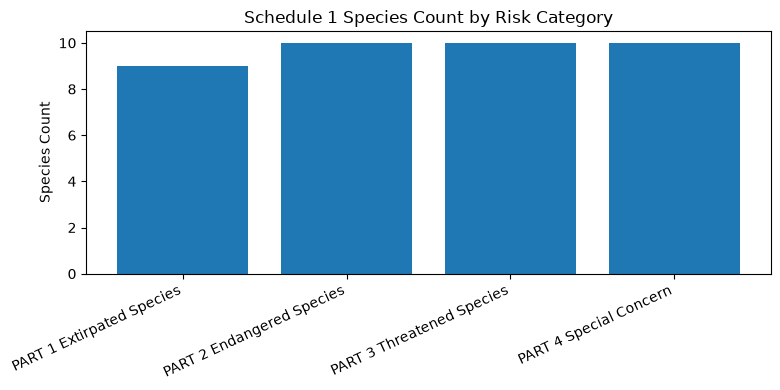

Species with explicit location mentions: 9
Species with no explicit location mention: 30


,location,species_mentions
0,Carolinian,2
1,Atlantic,2
2,Prairie,1
3,Pacific,1
4,St. Lawrence,1
5,Ontario,1
6,Saskatchewan,1


<Figure size 1000x600 with 0 Axes>

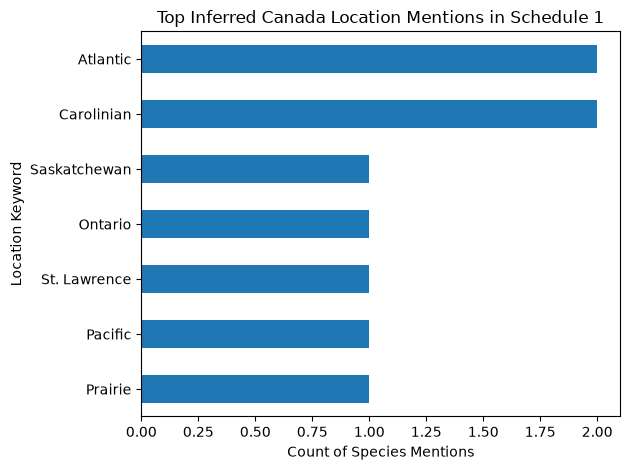

In [20]:
# Count species by legal risk category and infer location mentions in Canada
risk_counts = (
    species_df.groupby(['part_code', 'risk_category'], dropna=False)
    .size()
    .reset_index(name='species_count')
    .sort_values('part_code')
)

display(risk_counts)

plt.figure(figsize=(8, 4))
plt.bar(risk_counts['part_code'] + ' ' + risk_counts['risk_category'], risk_counts['species_count'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('Species Count')
plt.title('Schedule 1 Species Count by Risk Category')
plt.tight_layout()
plt.show()

location_keywords = [
    'Ontario', 'Quebec', 'Nova Scotia', 'New Brunswick', 'Manitoba',
    'British Columbia', 'Prince Edward Island', 'Saskatchewan',
    'Alberta', 'Newfoundland', 'Labrador', 'Yukon',
    'Northwest Territories', 'Nunavut',
    'Atlantic', 'Pacific', 'Arctic', 'Carolinian', 'Great Lakes',
    'St. Lawrence', 'Prairie', 'Hudson Bay', 'Maritime', 'Boreal'
]

def extract_location_mentions(text):
    matches = []
    text_lower = text.lower()
    for keyword in location_keywords:
        if keyword.lower() in text_lower:
            matches.append(keyword)
    return matches

species_df['location_mentions'] = species_df['species_en'].fillna('').apply(extract_location_mentions)
location_exploded = species_df.explode('location_mentions')
location_counts = (
    location_exploded['location_mentions']
    .dropna()
    .value_counts()
    .rename_axis('location')
    .reset_index(name='species_mentions')
)

print('Species with explicit location mentions:', int(species_df['location_mentions'].map(len).gt(0).sum()))
print('Species with no explicit location mention:', int(species_df['location_mentions'].map(len).eq(0).sum()))
display(location_counts.head(20))

if not location_counts.empty:
    plt.figure(figsize=(10, 6))
    location_counts.head(15).sort_values('species_mentions').plot(
        kind='barh', x='location', y='species_mentions', legend=False
    )
    plt.xlabel('Count of Species Mentions')
    plt.ylabel('Location Keyword')
    plt.title('Top Inferred Canada Location Mentions in Schedule 1')
    plt.tight_layout()
    plt.show()

In [21]:
# Helper: flatten one XML element into a row-friendly dictionary
def element_to_record(elem, prefix=''):
    record = {}

    # Include attributes
    for k, v in elem.attrib.items():
        record[f'{prefix}@{k}' if prefix else f'@{k}'] = v

    # Include element text when meaningful
    text = (elem.text or '').strip()
    if text:
        key = f'{prefix}#text' if prefix else '#text'
        record[key] = text

    # Include children recursively
    children = list(elem)
    if not children:
        return record

    tag_counts = {}
    for child in children:
        tag_counts[child.tag] = tag_counts.get(child.tag, 0) + 1

    seen = {}
    for child in children:
        seen[child.tag] = seen.get(child.tag, 0) + 1
        use_index = tag_counts[child.tag] > 1
        child_key = f'{child.tag}[{seen[child.tag]}]' if use_index else child.tag
        child_prefix = f'{prefix}{child_key}.' if prefix else f'{child_key}.'

        child_record = element_to_record(child, prefix=child_prefix)
        record.update(child_record)

    return record

In [22]:
# Convert XML to records for EDA
# Preferred assumption: each direct child under root is one logical record.
records = [element_to_record(child) for child in list(root)]

# Fallback if root does not contain multiple records
if len(records) <= 1:
    records = [element_to_record(root)]

df = pd.DataFrame(records)

print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()

Rows: 7
Columns: 10429


,@{http://justice.gc.ca/lims}inforce-start-date,@{http://justice.gc.ca/lims}fid,@{http://justice.gc.ca/lims}id,LongTitle.@{http://justice.gc.ca/lims}inforce-start-date,LongTitle.@{http://justice.gc.ca/lims}fid,LongTitle.@{http://justice.gc.ca/lims}id,LongTitle.#text,ShortTitle.@{http://justice.gc.ca/lims}inforce-start-date,ShortTitle.@{http://justice.gc.ca/lims}fid,ShortTitle.@{http://justice.gc.ca/lims}id,ShortTitle.@status,ShortTitle.#text,RunningHead.@{http://justice.gc.ca/lims}inforce-start-date,RunningHead.@{http://justice.gc.ca/lims}fid,RunningHead.@{http://justice.gc.ca/lims}id,RunningHead.#text,BillHistory.@{http://justice.gc.ca/lims}inforce-start-date,BillHistory.@{http://justice.gc.ca/lims}fid,BillHistory.@{http://justice.gc.ca/lims}id,BillHistory.Stages[1].@{http://justice.gc.ca/lims}inforce-start-date,BillHistory.Stages[1].@{http://justice.gc.ca/lims}fid,BillHistory.Stages[1].@{http://justice.gc.ca/lims}id,BillHistory.Stages[1].@stage,BillHistory.Stages[1].Date.YYYY.#text,BillHistory.Stages[1].Date.MM.#text,BillHistory.Stages[1].Date.DD.#text,BillHistory.Stages[2].@{http://justice.gc.ca/lims}inforce-start-date,BillHistory.Stages[2].@stage,BillHistory.Stages[2].Date.YYYY.#text,BillHistory.Stages[2].Date.MM.#text,BillHistory.Stages[2].Date.DD.#text,Chapter.@{http://justice.gc.ca/lims}inforce-start-date,Chapter.@{http://justice.gc.ca/lims}fid,Chapter.@{http://justice.gc.ca/lims}id,Chapter.ConsolidatedNumber.@official,Chapter.ConsolidatedNumber.#text,Chapter.AnnualStatuteId.@revised-statute,Chapter.AnnualStatuteId.AnnualStatuteNumber.#text,Chapter.AnnualStatuteId.YYYY.#text,Preamble.@{http://justice.gc.ca/lims}inforce-start-date,Preamble.@{http://justice.gc.ca/lims}fid,Preamble.@{http://justice.gc.ca/lims}id,Preamble.@salutation,Preamble.Provision[1].@{http://justice.gc.ca/lims}inforce-start-date,Preamble.Provision[1].@{http://justice.gc.ca/lims}fid,Preamble.Provision[1].@{http://justice.gc.ca/lims}id,Preamble.Provision[1].@format-ref,Preamble.Provision[1].@language-align,Preamble.Provision[1].@list-item,Preamble.Provision[1].MarginalNote.@{http://justice.gc.ca/lims}inforce-start-date,Preamble.Provision[1].MarginalNote.@{http://justice.gc.ca/lims}fid,Preamble.Provision[1].MarginalNote.@{http://justice.gc.ca/lims}id,Preamble.Provision[1].MarginalNote.#text,Preamble.Provision[1].Text.#text,Preamble.Provision[2].@{http://justice.gc.ca/lims}inforce-start-date,Preamble.Provision[2].@{http://justice.gc.ca/lims}fid,Preamble.Provision[2].@{http://justice.gc.ca/lims}id,Preamble.Provision[2].@format-ref,Preamble.Provision[2].@language-align,Preamble.Provision[2].@list-item,...,BilingualGroup[6].BilingualItemEn[6].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[6].Language.#text,BilingualGroup[6].BilingualItemFr[6].#text,BilingualGroup[6].BilingualItemEn[7].#text,BilingualGroup[6].BilingualItemEn[7].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[7].Language.#text,BilingualGroup[6].BilingualItemFr[7].#text,BilingualGroup[6].BilingualItemEn[8].#text,BilingualGroup[6].BilingualItemEn[8].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[8].Language.#text,BilingualGroup[6].BilingualItemFr[8].#text,BilingualGroup[6].BilingualItemEn[9].#text,BilingualGroup[6].BilingualItemEn[9].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[9].Language.#text,BilingualGroup[6].BilingualItemFr[9].#text,BilingualGroup[6].BilingualItemEn[10].#text,BilingualGroup[6].BilingualItemEn[10].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[10].Language.#text,BilingualGroup[6].BilingualItemFr[10].#text,BilingualGroup[6].BilingualItemEn[11].#text,BilingualGroup[6].BilingualItemEn[11].Language.@{http://www.w3.org/XML/1998/namespace}lang,BilingualGroup[6].BilingualItemEn[11].Language.#text,BilingualGroup[6].BilingualItemFr[11].#text,BilingualGroup[7].@{http://justice.gc.ca/lims

In [23]:
# Try to coerce numeric-looking columns
for col in df.columns:
    if df[col].dtype == 'object':
        candidate = pd.to_numeric(df[col], errors='coerce')
        # Convert only if most non-null values are numeric-like
        non_null = df[col].notna().sum()
        numeric_non_null = candidate.notna().sum()
        if non_null > 0 and numeric_non_null / non_null >= 0.8:
            df[col] = candidate

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Columns: 10429 entries, @{http://justice.gc.ca/lims}inforce-start-date to Amendment[10].AmendmentDate.#text
dtypes: str(10429)
memory usage: 570.5 KB


In [24]:
# Data quality overview
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(dropna=True)
}).sort_values(['null_pct', 'unique'], ascending=[False, True])

summary.head(30)

,dtype,non_null,nulls,null_pct,unique
LongTitle.@{http://justice.gc.ca/lims}inforce-start-date,str,1,6,85.71,1
LongTitle.@{http://justice.gc.ca/lims}fid,str,1,6,85.71,1
LongTitle.@{http://justice.gc.ca/lims}id,str,1,6,85.71,1
LongTitle.#text,str,1,6,85.71,1
ShortTitle.@{http://justice.gc.ca/lims}inforce-start-date,str,1,6,85.71,1
ShortTitle.@{http://justice.gc.ca/lims}fid,str,1,6,85.71,1
ShortTitle.@{http://justice.gc.ca/lims}id,str,1,6,85.71,1
ShortTitle.@status,str,1,6,85.71,1
ShortTitle.#text,str,1,6,85.71,1
RunningHead.@{http://justice.gc.ca/lims}inforce-start-date,str,1,6,85.71,1


In [25]:
# Duplicate check
dup_count = df.duplicated().sum()
print('Duplicate rows:', dup_count)

if dup_count > 0:
    display(df[df.duplicated()].head())

Duplicate rows: 0


In [26]:
# Numeric column statistics
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns:', len(num_cols))

if num_cols:
    display(df[num_cols].describe().T)
else:
    print('No numeric columns detected.')

Numeric columns: 0
No numeric columns detected.


In [27]:
# Categorical frequency snapshot
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print('Categorical/text columns:', len(cat_cols))

for col in cat_cols[:10]:
    print(f'\n--- {col} (top 10) ---')
    print(df[col].value_counts(dropna=False).head(10))

Categorical/text columns: 10429

--- @{http://justice.gc.ca/lims}inforce-start-date (top 10) ---
@{http://justice.gc.ca/lims}inforce-start-date
2012-06-29    3
2006-08-15    2
2018-05-30    1
NaN           1
Name: count, dtype: int64

--- @{http://justice.gc.ca/lims}fid (top 10) ---
@{http://justice.gc.ca/lims}fid
434468    1
434476    1
434500    1
435646    1
436317    1
436357    1
NaN       1
Name: count, dtype: int64

--- @{http://justice.gc.ca/lims}id (top 10) ---
@{http://justice.gc.ca/lims}id
434468    1
434476    1
434500    1
435646    1
436317    1
436357    1
NaN       1
Name: count, dtype: int64

--- LongTitle.@{http://justice.gc.ca/lims}inforce-start-date (top 10) ---
LongTitle.@{http://justice.gc.ca/lims}inforce-start-date
NaN           6
2012-06-29    1
Name: count, dtype: int64

--- LongTitle.@{http://justice.gc.ca/lims}fid (top 10) ---
LongTitle.@{http://justice.gc.ca/lims}fid
NaN       6
434469    1
Name: count, dtype: int64

--- LongTitle.@{http://justice.gc.ca/lims

/var/folders/g8/45jnc14159517h27k04t6w_h0000gq/T/ipykernel_18546/2247687136.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


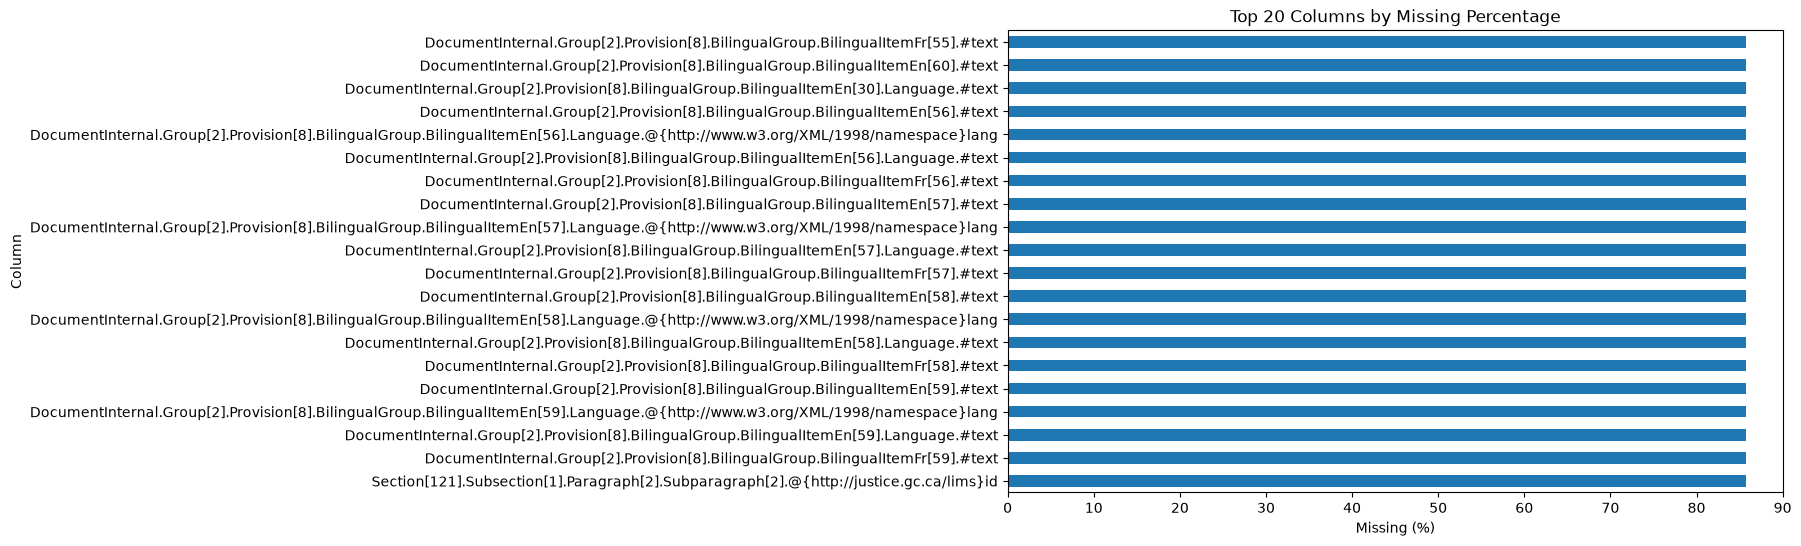

In [28]:
# Missingness plot for top columns with most nulls
top_missing = (df.isna().mean() * 100).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_missing.sort_values().plot(kind='barh')
plt.xlabel('Missing (%)')
plt.ylabel('Column')
plt.title('Top 20 Columns by Missing Percentage')
plt.tight_layout()
plt.show()

In [29]:
# Histograms for up to 12 numeric fields
if num_cols:
    plot_cols = num_cols[:12]
    df[plot_cols].hist(figsize=(14, 8), bins=30)
    plt.suptitle('Numeric Distributions', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric distributions to plot.')

No numeric distributions to plot.


## Next Steps

- If records are nested differently, adjust the record extraction logic to the correct entity level.
- Add domain-specific checks (e.g., date validity, expected enumerations, range checks).
- Export the flattened table for downstream analysis:

```python
output_csv = os.path.join(data_dir, 'S-15.3_flattened.csv')
df.to_csv(output_csv, index=False)
```